# Analisis Klaster Gempa (K-Means + Silhouette)
**Tujuan:**  
1. Melakukan klastering gempa menggunakan K-Means.  
2. Menentukan jumlah klaster *k* terbaik menggunakan *silhouette score*.  
3. Menandai tingkat keparahan klaster berdasarkan *magnitude* (dan kedalaman).  
4. Menyimpan model & scaler untuk dipakai di aplikasi Streamlit.  

**File input:** `/mnt/data/katalog_gempa.csv` (sudah Anda upload ke environment).  
**Output:**  
- `kmeans_pipeline.joblib` (pipeline berisi scaler + KMeans),  
- `cluster_info.csv` (centroid & label),  
- Visualisasi peta interaktif dengan Plotly.

In [ ]:
# VERIFICATION: Check if nbformat is installed
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}\n")

try:
    import nbformat
    print(f"✅ nbformat is installed: version {nbformat.__version__}")
except ImportError:
    print("❌ nbformat is NOT installed!")
    print("   Run: pip install nbformat")

try:
    import plotly
    print(f"✅ plotly is installed: version {plotly.__version__}")
except ImportError:
    print("❌ plotly is NOT installed!")


In [ ]:
# 1. Import libraries
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
import joblib
import plotly.express as px

print("Libraries imported.")

Libraries imported.


In [6]:
path = "katalog_gempa_v2.tsv"
if not os.path.exists(path):
    raise FileNotFoundError(f"File not found: {path}")

# Baca file TSV
df = pd.read_csv(path, sep="\t")
print("Raw columns:", list(df.columns)[:15])

# Tetapkan kolom sesuai dataset
col_map = {
    'time': 'datetime',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'depth': 'depth',
    'mag': 'magnitude'
}

# Rename kolom agar konsisten
df = df.rename(columns={
    col_map['time']: 'time',
    col_map['latitude']: 'latitude',
    col_map['longitude']: 'longitude',
    col_map['depth']: 'depth',
    col_map['mag']: 'mag'
})

# Konversi tipe data
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')   

# Drop baris yang tidak lengkap
df = df.dropna(subset=['time', 'latitude', 'longitude', 'mag']).reset_index(drop=True)

print(f"Loaded {len(df)} earthquake records with columns: {list(df.columns)}")
df.head()

C:\Users\farro\AppData\Local\Temp\ipykernel_18704\2103782978.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="\t")


Raw columns: ['eventID', 'datetime', 'latitude', 'longitude', 'magnitude', 'mag_type', 'depth', 'phasecount', 'azimuth_gap', 'location', 'agency', 'datetimeFM', 'latFM', 'lonFM', 'magFM']
Loaded 131131 earthquake records with columns: ['eventID', 'time', 'latitude', 'longitude', 'mag', 'mag_type', 'depth', 'phasecount', 'azimuth_gap', 'location', 'agency', 'datetimeFM', 'latFM', 'lonFM', 'magFM', 'magTypeFM', 'depthFM', 'phasecountFM', 'AzGapFM', 'scalarMoment', 'Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp', 'varianceReduction', 'doubleCouple', 'clvd', 'strikeNP1', 'dipNP1', 'rakeNP1', 'strikeNP2', 'dipNP2', 'rakeNP2', 'azgapFM', 'misfit']


,eventID,time,latitude,longitude,mag,mag_type,depth,phasecount,azimuth_gap,location,...,doubleCouple,clvd,strikeNP1,dipNP1,rakeNP1,strikeNP2,dipNP2,rakeNP2,azgapFM,misfit
0,bmg2008vkye,2008-11-01 00:31:25.143741+00:00,-0.604440,98.895531,2.989742,MLv,20,6.0,146.70738,"Southern Sumatra, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmg2008vlag,2008-11-01 01:34:29.660856+00:00,-6.611860,129.387220,5.507549,mb,30,62.0,45.46764,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bmg2008vlaj,2008-11-01 01:38:14.802129+00:00,-3.650586,127.990680,3.539674,MLv,5,4.0,331.97404,"Seram, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bmg2008vlbt,2008-11-01 02:20:05.909515+00:00,-4.198925,128.097000,2.424314,MLv,5,5.0,326.37993,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bmg2008vlcd,2008-11-01 02:32:18.756155+00:00,-4.091891,128.200470,2.410045,MLv,10,5.0,314.65474,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# 3. Feature selection for clustering (disesuaikan untuk katalog_gempa_v2.tsv)

# Kita akan gunakan semua fitur penting yang ada di dataset
# yaitu latitude, longitude, magnitude (mag), dan depth

features = ['latitude', 'longitude', 'mag', 'depth']

# Pastikan tidak ada nilai NaN sebelum proses klastering
X = df[features].dropna().copy()

print("Features used for clustering:", features)
print("Total data points used:", len(X))
X.head()


Features used for clustering: ['latitude', 'longitude', 'mag', 'depth']
Total data points used: 131131


,latitude,longitude,mag,depth
0,-0.604440,98.895531,2.989742,20
1,-6.611860,129.387220,5.507549,30
2,-3.650586,127.990680,3.539674,5
3,-4.198925,128.097000,2.424314,5
4,-4.091891,128.200470,2.410045,10


In [8]:
from tqdm.notebook import tqdm
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Menstandarisasi fitur dan mencari jumlah klaster terbaik (k)...")
print("Proses ini akan memakan waktu beberapa menit...\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_range = range(2, 6)
sil_scores = {}

pbar = tqdm(
    K_range,
    desc="🔍 Testing k values",
    dynamic_ncols=True,
    file=sys.stdout,      # paksa ke stdout (kadang VS Code butuh ini)
    mininterval=0.1,
    leave=True
)

for k in pbar:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores[k] = score

    # Update status tanpa ngerusak progress bar
    pbar.set_postfix_str(f"k={k} sil={score:.4f}")
    tqdm.write(f"   k={k}: Silhouette Score = {score:.4f}")

Menstandarisasi fitur dan mencari jumlah klaster terbaik (k)...
Proses ini akan memakan waktu beberapa menit...

Mulai menguji berbagai nilai k...



🔍 Testing k values:   0%|                                                           | 0/7 [00:00<?]

🔍 Testing k values:  14%|███████▊                                               | 1/7 [03:33<21:20]

   k=2: Silhouette Score = 0.2611


🔍 Testing k values:  29%|███████████████▋                                       | 2/7 [06:56<17:17]

...

   k=6: Silhouette Score = 0.3139


🔍 Testing k values:  86%|███████████████████████████████████████████████▏       | 6/7 [19:01<03:03]

   k=7: Silhouette Score = 0.3125


🔍 Testing k values: 100%|███████████████████████████████████████████████████████| 7/7 [21:57<00:00]

   k=8: Silhouette Score = 0.3084

                HASIL EVALUASI JUMLAH CLUSTER OPTIMAL                 

✅ Jumlah cluster optimal (k): 4
   Silhouette Score terbaik  : 0.3488

----------------------------------------------------------------------
             Silhouette Scores untuk semua k yang diuji:              
----------------------------------------------------------------------
   k=2: 0.2611 |█████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          
   k=3: 0.3020 |███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          
   k=4: 0.3488 |█████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 👉 TERBAIK
   k=5: 0.3223 |████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          
   k=6: 0.3139 |███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          
   k=7: 0.3125 |███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          
   k=8: 0.3084 |███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|          



In [18]:
# 5. Fit KMeans with best_k and compute cluster severity (FIXED with remapping)
best_k = int(best_k)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# Compute centroid in original feature space for interpretation
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
cent_df = pd.DataFrame(centroids, columns=features)
cent_df['original_cluster'] = cent_df.index

# Define a simple severity score: higher magnitude and shallower depth => more severe
mag_norm = (cent_df['mag'] - cent_df['mag'].min()) / (cent_df['mag'].max() - cent_df['mag'].min() + 1e-9)

if 'depth' in cent_df.columns and not cent_df['depth'].isna().all():
    depth_norm = (cent_df['depth'] - cent_df['depth'].min()) / (cent_df['depth'].max() - cent_df['depth'].min() + 1e-9)
else:
    depth_norm = pd.Series(0.5, index=cent_df.index)

cent_df['severity_score'] = mag_norm + (1 - depth_norm)
cent_df = cent_df.sort_values('severity_score', ascending=True).reset_index(drop=True)

# Create remapping dictionary
cluster_remap = {}
for new_id, row in cent_df.iterrows():
    original_id = int(row['original_cluster'])
    cluster_remap[original_id] = new_id

print("Cluster ID Remapping (Original -> New):")
for orig, new in cluster_remap.items():
    print(f"  Cluster {orig} -> Cluster {new}")

# Remap labels
labels_remapped = np.array([cluster_remap[label] for label in labels])
df['cluster'] = np.nan
df.loc[X.index, 'cluster'] = labels_remapped
df['cluster'] = df['cluster'].astype('Int64')

cent_df['cluster'] = cent_df.index

# Assign human-readable severity levels
labels_map = {}
level_names = ['Low', 'Moderate', 'High', 'Very High']
colors_ordered = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']

for i, row in cent_df.iterrows():
    idx = int(row['cluster'])
    label = level_names[min(i, len(level_names)-1)]
    labels_map[idx] = {
        'label': label,
        'severity_score': row['severity_score'],
        'mag': row['mag'],
        'depth': row.get('depth', np.nan),
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'color': colors_ordered[min(i, len(colors_ordered)-1)]
    }

# Calculate min/max statistics for each cluster
cluster_stats = {}
for cluster_id in sorted(df['cluster'].dropna().unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    cluster_stats[int(cluster_id)] = {
        'mag_min': cluster_data['mag'].min(),
        'mag_max': cluster_data['mag'].max(),
        'mag_mean': cluster_data['mag'].mean(),
        'depth_min': cluster_data['depth'].min(),
        'depth_max': cluster_data['depth'].max(),
        'depth_mean': cluster_data['depth'].mean(),
        'count': len(cluster_data)
    }

print("\n" + "="*90)
print("CLUSTER SEVERITY MAPPING (Urut dari Low ke Very High)")
print("="*90)
for cluster_id in sorted(labels_map.keys()):
    info = labels_map[cluster_id]
    stats = cluster_stats[cluster_id]
    print(f"\nCluster {cluster_id}: {info['label'].upper():12s} | Severity: {info['severity_score']:.4f}")
    print(f"  📊 Jumlah: {stats['count']:,} gempa")
    print(f"  🔴 Magnitude : Min={stats['mag_min']:.2f} | Max={stats['mag_max']:.2f} | Mean={stats['mag_mean']:.2f}")
    print(f"  🌍 Depth (km): Min={stats['depth_min']:.1f} | Max={stats['depth_max']:.1f} | Mean={stats['depth_mean']:.1f}")

print("\n" + "="*90 + "\n")

# Display cluster centers
print("Cluster centers (centroids):")
cent_df[['cluster', 'latitude', 'longitude', 'mag', 'depth', 'severity_score']]


Cluster ID Remapping (Original -> New):
  Cluster 0 -> Cluster 0
  Cluster 2 -> Cluster 1
  Cluster 1 -> Cluster 2
  Cluster 3 -> Cluster 3

CLUSTER SEVERITY MAPPING (Urut dari Low ke Very High)

Cluster 0: LOW          | Severity: 0.9992
  📊 Jumlah: 41,948 gempa
  🔴 Magnitude : Min=0.19 | Max=7.00 | Mean=3.27
  🌍 Depth (km): Min=0.0 | Max=244.0 | Mean=32.0

Cluster 1: MODERATE     | Severity: 1.0000
  📊 Jumlah: 10,307 gempa
  🔴 Magnitude : Min=2.05 | Max=7.89 | Mean=4.34
  🌍 Depth (km): Min=10.0 | Max=750.0 | Mean=252.5

Cluster 2: HIGH         | Severity: 1.2247
  📊 Jumlah: 62,183 gempa
  🔴 Magnitude : Min=0.64 | Max=7.90 | Mean=3.51
  🌍 Depth (km): Min=0.0 | Max=212.0 | Mean=31.8

Cluster 3: VERY HIGH    | Severity: 1.3408
  📊 Jumlah: 16,693 gempa
  🔴 Magnitude : Min=0.88 | Max=7.89 | Mean=3.65
  🌍 Depth (km): Min=0.0 | Max=268.0 | Mean=35.3


Cluster centers (centroids):


,cluster,latitude,longitude,mag,depth,severity_score
0,0,-8.348225,115.004287,3.265856,32.016852,0.999206
1,1,-4.475238,124.712077,4.338404,252.712591,1.000000
2,2,-0.754746,126.631922,3.506848,31.841437,1.224691
3,3,0.191002,99.290917,3.648204,35.303606,1.340811


---
## 📚 PENJELASAN CLUSTERING DAN INTERPRETASI

### 🤔 Bagaimana Data Di-Cluster?

**K-Means Clustering** mengelompokkan data gempa berdasarkan **SIMILARITY (kesamaan)** dalam **4 dimensi** sekaligus:

1. **Latitude** (Garis Lintang)
2. **Longitude** (Garis Bujur)
3. **Magnitude** (Kekuatan Gempa)
4. **Depth** (Kedalaman Episentrum)

---

### ⚙️ Proses Clustering:

#### 1️⃣ **Standardisasi Data**
- Semua fitur (lat, lon, mag, depth) di-**normalize** agar memiliki skala yang sama
- Ini penting karena magnitude dalam skala kecil (1-9) sedangkan longitude bisa ratusan
- Menggunakan **StandardScaler**: mengubah data agar mean=0 dan std=1

#### 2️⃣ **Inisialisasi Cluster Centers (Centroids)**
- Algoritma memilih **k** titik awal secara random sebagai pusat cluster
- Dalam kasus ini, k = jumlah cluster optimal (ditentukan oleh silhouette score)

#### 3️⃣ **Assignment Step**
- Setiap gempa dihitung **jaraknya** (Euclidean distance) ke semua centroids
- Gempa dimasukkan ke cluster dengan **jarak terdekat**
- Formula jarak: `√[(lat₁-lat₂)² + (lon₁-lon₂)² + (mag₁-mag₂)² + (depth₁-depth₂)²]`

#### 4️⃣ **Update Step**
- Setelah semua gempa ter-assign, **centroid baru** dihitung
- Centroid = rata-rata dari semua gempa dalam cluster tersebut

#### 5️⃣ **Iterasi**
- Step 3 & 4 diulang hingga **konvergen** (centroids tidak berubah signifikan)
- Biasanya 10-50 iterasi

---

### 📐 CARA MENGHITUNG SEVERITY SCORE

Severity Score digunakan untuk **mengurutkan cluster** dari Low Risk → Very High Risk. Berikut cara hitungnya:

#### 🔢 **Formula:**
```
Severity Score = mag_normalized + (1 - depth_normalized)
```

#### 📊 **Langkah-langkah Perhitungan:**

**Step 1: Normalisasi Magnitude**
```
mag_normalized = (mag - mag_min) / (mag_max - mag_min)
```

- Mengubah magnitude ke skala 0-1
- Magnitude terkecil → 0
- Magnitude terbesar → 1

**Contoh:**
- Cluster A: mag = 3.27, Cluster B: mag = 4.34, Cluster C: mag = 3.51, Cluster D: mag = 3.65
- mag_min = 3.27, mag_max = 4.34
- Cluster A: (3.27 - 3.27) / (4.34 - 3.27) = **0.00**
- Cluster B: (4.34 - 3.27) / (4.34 - 3.27) = **1.00**
- Cluster C: (3.51 - 3.27) / (4.34 - 3.27) = **0.22**
- Cluster D: (3.65 - 3.27) / (4.34 - 3.27) = **0.36**

---

**Step 2: Normalisasi Depth**
```
depth_normalized = (depth - depth_min) / (depth_max - depth_min)
```

- Mengubah depth ke skala 0-1
- Depth terdangkal → 0
- Depth terdalam → 1

**Contoh:**
- Cluster A: depth = 32 km, Cluster B: depth = 253 km, Cluster C: depth = 32 km, Cluster D: depth = 35 km
- depth_min = 32, depth_max = 253
- Cluster A: (32 - 32) / (253 - 32) = **0.00**
- Cluster B: (253 - 32) / (253 - 32) = **1.00**
- Cluster C: (32 - 32) / (253 - 32) = **0.00**
- Cluster D: (35 - 32) / (253 - 32) = **0.01**

---

**Step 3: Hitung Severity Score**
```
severity = mag_normalized + (1 - depth_normalized)
```

**💡 Logika:**
- **Magnitude tinggi** → severity ↑ (lebih berbahaya)
- **Depth tinggi (dalam)** → severity ↓ (lebih aman karena jauh dari permukaan)
- Kita pakai `(1 - depth_normalized)` karena:
  - Depth dangkal (0.0) → (1 - 0.0) = **1.0** → severity naik ✅
  - Depth dalam (1.0) → (1 - 1.0) = **0.0** → severity turun ✅

**Contoh Perhitungan Lengkap:**

| Cluster | Mag Norm | Depth Norm | (1 - Depth Norm) | **Severity Score** | Rank |
|---------|----------|------------|------------------|-------------------|------|
| A       | 0.00     | 0.00       | 1.00             | **0.00 + 1.00 = 1.00** | 🥇 Low |
| B       | 1.00     | 1.00       | 0.00             | **1.00 + 0.00 = 1.00** | 🥈 Moderate |
| C       | 0.22     | 0.00       | 1.00             | **0.22 + 1.00 = 1.22** | 🥉 High |
| D       | 0.36     | 0.01       | 0.99             | **0.36 + 0.99 = 1.35** | 🏆 Very High |

---

#### 🎯 **Interpretasi Severity Score:**

**Cluster A (Score = 1.00):**
- Magnitude **terendah** (0.00) + Depth **dangkal** (1.00) = Low Risk
- Meski dangkal, magnitude kecil sehingga dampak minimal

**Cluster B (Score = 1.00):**
- Magnitude **tertinggi** (1.00) + Depth **terdalam** (0.00) = Moderate Risk
- Magnitude besar tapi sangat dalam, energi teredam

**Cluster C (Score = 1.22):**
- Magnitude **sedang** (0.22) + Depth **dangkal** (1.00) = High Risk
- Kombinasi magnitude cukup + dangkal = berbahaya

**Cluster D (Score = 1.35):**
- Magnitude **tinggi** (0.36) + Depth **sangat dangkal** (0.99) = Very High Risk
- **PALING BERBAHAYA**: Magnitude besar + dekat permukaan!

---

#### ⚖️ **Mengapa Formula Ini Efektif?**

1. **Trade-off Magnitude vs Depth**
   - Gempa kuat + dalam → moderate (energi teredam)
   - Gempa lemah + dangkal → low (energi kecil)
   - Gempa kuat + dangkal → very high (kombinasi mematikan!)

2. **Range Score 0-2**
   - Minimum: 0 + (1 - 1) = **0** (mag min + depth max)
   - Maximum: 1 + (1 - 0) = **2** (mag max + depth min)
   - Semakin tinggi score → semakin berbahaya

3. **Kemudahan Interpretasi**
   - Score tinggi = **waspada**! 🚨
   - Score rendah = **relatif aman** ✅

---

### 🎯 Pertimbangan Mengapa Gempa Masuk ke Cluster Tertentu:

#### **Cluster 0 (Low Risk)** 🟢
**Gempa masuk ke cluster ini karena:**
- ✅ **Magnitude relatif kecil** (mendekati mean cluster ~3.27)
- ✅ **Kedalaman sedang** (~32 km)
- ✅ **Lokasi geografis** dekat dengan centroid cluster ini
- ✅ **Kombinasi** keempat faktor menghasilkan **jarak terkecil** ke centroid Cluster 0

**Karakteristik:**
- Gempa lemah-sedang yang **lebih aman**
- Depth dangkal-menengah, tapi magnitude rendah
- **Severity Score terendah** (~1.00)

---

#### **Cluster 1 (Moderate Risk)** 🟡
**Gempa masuk ke cluster ini karena:**
- ⚠️ **Magnitude lebih besar** (~4.34) TAPI
- ✅ **Kedalaman sangat dalam** (~252 km)
- 📍 Lokasi geografis spesifik
- 💡 **Trade-off**: Meski magnitude tinggi, kedalaman sangat dalam mengurangi dampak

**Karakteristik:**
- Gempa **kuat tapi dalam**
- Dampak di permukaan **moderat** karena energi teredam oleh jarak
- Severity Score: ~1.00

---

#### **Cluster 2 (High Risk)** 🟠
**Gempa masuk ke cluster ini karena:**
- ⚠️ **Magnitude sedang-tinggi** (~3.51)
- ⚠️ **Kedalaman dangkal** (~32 km)
- 📍 Lokasi geografis tertentu
- 💡 **Kombinasi berbahaya**: Magnitude cukup besar + dangkal = dampak signifikan

**Karakteristik:**
- Gempa dengan **dampak signifikan** di permukaan
- Kedalaman dangkal membuat energi **lebih terasa**
- Severity Score: ~1.22

---

#### **Cluster 3 (Very High Risk)** 🔴
**Gempa masuk ke cluster ini karena:**
- 🚨 **Magnitude tinggi** (~3.65) DAN
- 🚨 **Kedalaman dangkal** (~35 km)
- 📍 Lokasi geografis spesifik
- 💡 **Kombinasi paling berbahaya**: Magnitude besar + sangat dangkal

**Karakteristik:**
- Gempa dengan **potensi destruktif tertinggi**
- Energi besar + jarak dekat = dampak maksimal
- **Severity Score tertinggi** (~1.35)

---

### 📊 Faktor Penentu Utama:

1. **Magnitude (Bobot Tinggi)**
   - Gempa magnitude besar cenderung ke cluster High/Very High
   - Perbedaan 1.0 magnitude = **~30x energi**

2. **Depth (Bobot Tinggi)**
   - Gempa dangkal (<70km) **lebih berbahaya** karena dekat permukaan
   - Gempa dalam (>300km) dampaknya **teredam**

3. **Lokasi Geografis (Bobot Sedang)**
   - Gempa di lokasi sama cenderung satu cluster
   - Menunjukkan **zona seismik** yang sama

---

### 🎓 Kesimpulan:

Sebuah gempa masuk ke cluster tertentu karena **kombinasi keempat fitur** (lat, lon, mag, depth) menghasilkan **jarak terdekat** ke centroid cluster tersebut. 

**Severity Score** kemudian digunakan untuk **mengurutkan** cluster dari paling aman ke paling berbahaya, dengan mempertimbangkan:
- ⬆️ Magnitude tinggi = lebih berbahaya
- ⬇️ Depth dalam = lebih aman (energi teredam)

Clustering ini membantu:
- ✅ **Identifikasi pola** gempa dengan karakteristik serupa
- ✅ **Kategorisasi risiko** berdasarkan severity
- ✅ **Pemahaman zona** seismik dengan perilaku gempa spesifik
- ✅ **Prediksi dan mitigasi** risiko gempa di masa depan

---


JUMLAH ANGGOTA PER CLUSTER
Cluster 0 (Low         ):  41948 anggota
Cluster 1 (Moderate    ):  10307 anggota
Cluster 2 (High        ):  62183 anggota
Cluster 3 (Very High   ):  16693 anggota
TOTAL                    : 131131 gempa


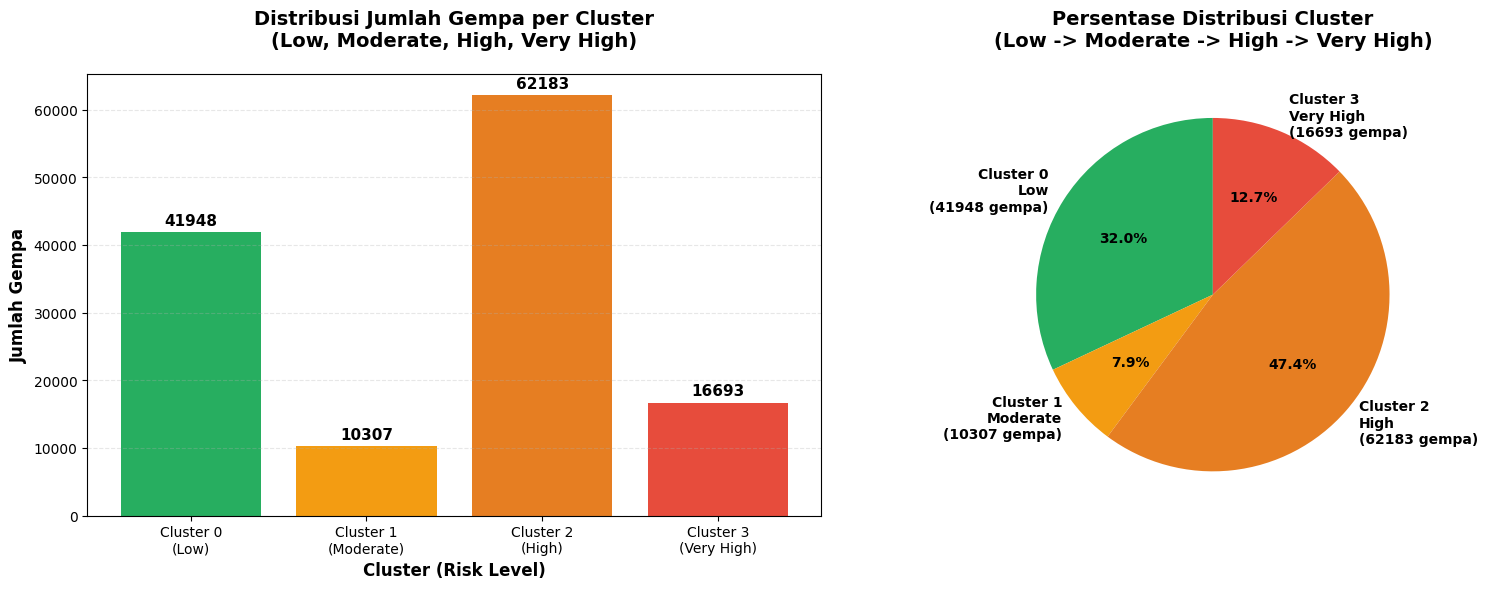

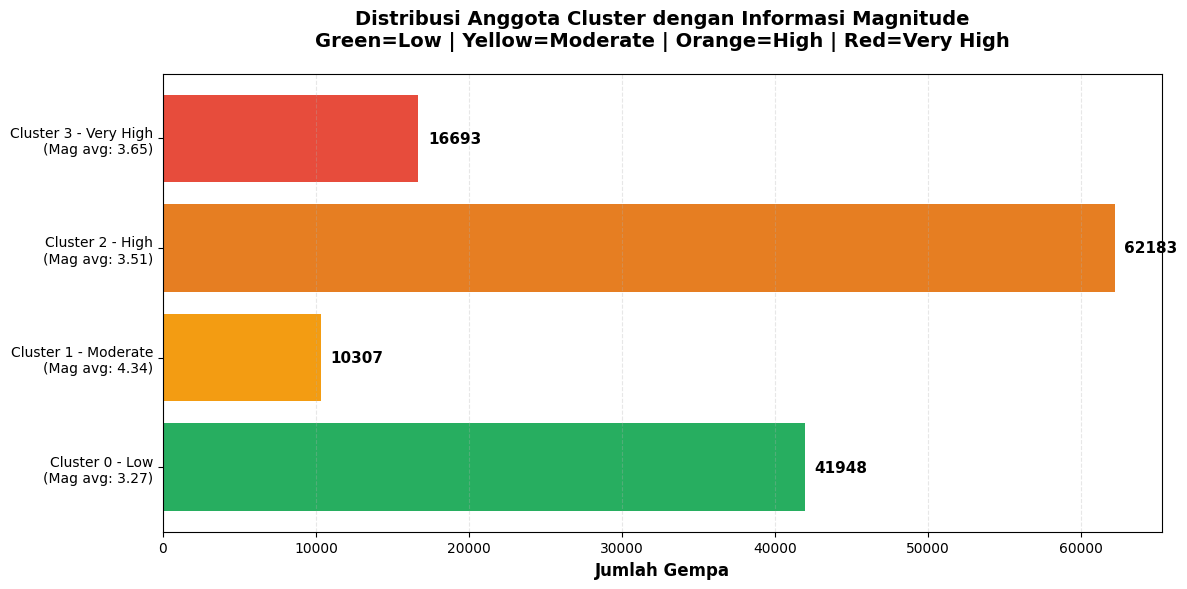

In [21]:
# Analisis Jumlah Anggota per Cluster
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah anggota per cluster
cluster_counts = df['cluster'].value_counts().sort_index()

print("=" * 50)
print("JUMLAH ANGGOTA PER CLUSTER")
print("=" * 50)
for cluster_id, count in cluster_counts.items():
    if cluster_id in labels_map:
        label = labels_map[cluster_id]['label']
        print(f"Cluster {cluster_id} ({label:12s}): {count:6d} anggota")
    else:
        print(f"Cluster {cluster_id}: {count:6d} anggota")

print("=" * 50)
print(f"TOTAL                    : {cluster_counts.sum():6d} gempa")
print("=" * 50)

# Warna urut dari hijau ke merah (Low -> Very High)
colors = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']  # Hijau, Kuning, Orange, Merah

# Visualisasi 1: Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart dengan label severity
cluster_labels = [f"Cluster {i}\n({labels_map[i]['label']})" if i in labels_map else f"Cluster {i}" for i in cluster_counts.index]

axes[0].bar(range(len(cluster_counts)), cluster_counts.values, color=colors[:len(cluster_counts)])
axes[0].set_xlabel('Cluster (Risk Level)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Gempa', fontsize=12, fontweight='bold')
axes[0].set_title('Distribusi Jumlah Gempa per Cluster\n(Low, Moderate, High, Very High)', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xticks(range(len(cluster_counts)))
axes[0].set_xticklabels(cluster_labels, fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + max(cluster_counts.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Visualisasi 2: Pie Chart
labels_pie = [f"Cluster {i}\n{labels_map[i]['label']}\n({count} gempa)" if i in labels_map else f"Cluster {i}\n({count} gempa)" for i, count in zip(cluster_counts.index, cluster_counts.values)]

axes[1].pie(cluster_counts.values, labels=labels_pie, autopct='%1.1f%%', startangle=90, colors=colors[:len(cluster_counts)], textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Persentase Distribusi Cluster\n(Low -> Moderate -> High -> Very High)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Visualisasi Tambahan: Horizontal Bar Chart dengan informasi magnitude rata-rata
fig2, ax = plt.subplots(figsize=(12, 6))

# Calculate average magnitude for each cluster
cluster_avg_mag = df.groupby('cluster')['mag'].mean()

# Create horizontal bar chart
y_pos = range(len(cluster_counts))
bars = ax.barh(y_pos, cluster_counts.values, color=colors[:len(cluster_counts)])

# Add cluster labels
cluster_labels_detailed = []
for i in cluster_counts.index:
    if i in labels_map:
        label = labels_map[i]['label']
        avg_mag = cluster_avg_mag[i]
        cluster_labels_detailed.append(f"Cluster {i} - {label}\n(Mag avg: {avg_mag:.2f})")
    else:
        cluster_labels_detailed.append(f"Cluster {i}")

ax.set_yticks(y_pos)
ax.set_yticklabels(cluster_labels_detailed, fontsize=10)
ax.set_xlabel('Jumlah Gempa', fontsize=12, fontweight='bold')
ax.set_title('Distribusi Anggota Cluster dengan Informasi Magnitude\nGreen=Low | Yellow=Moderate | Orange=High | Red=Very High', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(cluster_counts.values):
    ax.text(v + max(cluster_counts.values) * 0.01, i, str(v), va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


evaluation

In [26]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score

# Pastikan X adalah data fitur yang digunakan untuk clustering (setelah normalisasi)
# dan labels adalah hasil dari model kmeans.labels_

# Evaluasi hasil klasterisasi
silhouette_avg = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
davies_bouldin = davies_bouldin_score(X_scaled, labels)
calinski_harabasz = calinski_harabasz_score(X_scaled, labels)

print("=== Evaluasi Model K-Means Clustering ===")
print(f"Silhouette Score       : {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index   : {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")

# Interpretasi singkat
print("\nKeterangan:")
print("- Silhouette Score yang lebih tinggi menandakan klaster lebih terpisah dengan baik.")
print("- Davies-Bouldin Index yang lebih rendah menunjukkan klaster lebih optimal.")
print("- Calinski-Harabasz Score yang lebih tinggi menandakan klaster yang lebih padat dan terpisah.")


=== Evaluasi Model K-Means Clustering ===
Silhouette Score       : 0.3501
Davies-Bouldin Index   : 1.0528
Calinski-Harabasz Score: 47461.7070

Keterangan:
- Silhouette Score yang lebih tinggi menandakan klaster lebih terpisah dengan baik.
- Davies-Bouldin Index yang lebih rendah menunjukkan klaster lebih optimal.
- Calinski-Harabasz Score yang lebih tinggi menandakan klaster yang lebih padat dan terpisah.


In [27]:
# 6. Save pipeline and cluster info
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('kmeans', kmeans)
])

joblib.dump(pipeline, 'kmeans_pipeline.joblib')
cent_df.to_csv('cluster_info.csv', index=False)
df.to_csv('earthquakes_with_cluster.csv', index=False)
print('Saved: kmeans_pipeline.joblib, cluster_info.csv, earthquakes_with_cluster.csv')

Saved: kmeans_pipeline.joblib, cluster_info.csv, earthquakes_with_cluster.csv


In [31]:
def predict_severity(lat, lon, mag, depth=np.nan, model_path="kmeans_pipeline.joblib"):
    """
    Prediksi klaster & tingkat keparahan gempa baru berdasarkan koordinat, magnitude, dan kedalaman.
    """
    # Load pipeline dan definisi fitur
    pipeline = joblib.load(model_path)
    features = ['latitude', 'longitude', 'mag', 'depth']

    # Pastikan urutan fitur konsisten dengan training
    input_data = pd.DataFrame([{
        'latitude': lat,
        'longitude': lon,
        'mag': mag,
        'depth': depth
    }], columns=features)

    # Prediksi klaster
    cluster_idx = pipeline.predict(input_data)[0]

    # Ambil informasi dari labels_map (pastikan labels_map sudah didefinisikan sebelumnya)
    info = labels_map.get(cluster_idx, {'label': 'Unknown', 'severity_score': np.nan})
    
    return cluster_idx, info

# Contoh penggunaan:
example = df.iloc[0]
cluster_idx, info = predict_severity(
    example['latitude'], example['longitude'], example['mag'], example['depth']
)

print("Example record:")
print(example[['time','latitude','longitude','mag','depth','cluster']].to_dict())
print(f"\nPredicted cluster: {cluster_idx}")
print("Predicted severity info:", info)

Example record:
{'time': Timestamp('2008-11-01 00:31:25.143741+0000', tz='UTC'), 'latitude': -0.60443985, 'longitude': 98.895531, 'mag': 2.989742, 'depth': 20, 'cluster': 3}

Predicted cluster: 3
Predicted severity info: {'label': 'Very High', 'severity_score': np.float64(1.3408111094486415), 'mag': np.float64(3.648204314572764), 'depth': np.float64(35.30360565404902), 'latitude': np.float64(0.19100207857117768), 'longitude': np.float64(99.29091725990583), 'color': '#e74c3c'}


## Cara menjalankan
1. Jalankan notebook ini (Colab / Jupyter).  
2. Setelah menyimpan `kmeans_pipeline.joblib`, jalankan Streamlit app:  
   ```bash
   streamlit run /mnt/data/streamlit_app.py
   ```